<a href="https://colab.research.google.com/github/falabio/CO2-Emission-Analysis/blob/main/co2_emission_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CO2 Emission by Countries Analysis

## Project Title and Overview
This project performs an exploratory data analysis (EDA) on CO2 emissions by countries, spanning from 1750 to 2020. The primary goal is to understand global CO2 emission trends, identify major contributing countries, and analyze specific country-level patterns. The dataset used is `CO2 emission by countries.csv`, which contains historical CO2 emission data along with country-specific information.

## Goals
*   To load and clean the CO2 emission dataset.
*   To generate comprehensive data profiles for both raw and cleaned data.
*   To identify and visualize the top CO2 emitting countries.
*   To analyze the overall yearly trend of CO2 emissions.
*   To examine the CO2 emission trends and ranking for a specific country (e.g., United States) over time.
*   To detect outliers in the CO2 emission data.

## Methodology
The analysis involved the following steps:
1.  **Data Loading:** The `CO2 emission by countries.csv` dataset was loaded into a pandas DataFrame using `pd.read_csv`, with `latin1` encoding to handle potential character issues.
2.  **Initial Data Profiling:** `ydata-profiling` was used to generate a detailed report of the raw data (`CO2_emission_by_countries_raw_report.html`), providing insights into data types, missing values, and initial distributions.
3.  **Data Cleaning and Preprocessing:**
    *   Filtered the dataset to include only records where 'CO2 emission (Tons)' is greater than 0, as zero values likely represent missing data or periods before significant industrialization.
    *   Selected relevant columns: 'Country', 'Year', and 'CO2 emission (Tons)'.
    *   Checked for missing values in the cleaned dataset.
4.  **Cleaned Data Profiling:** Another `ydata-profiling` report (`cleanedco2_profile.html`) was generated for the cleaned data to reflect the changes after preprocessing.
5.  **Descriptive Analysis:** Basic descriptive statistics were computed for the cleaned CO2 emission data.
6.  **Outlier Detection:** The Interquartile Range (IQR) method was applied to identify potential outliers in the 'CO2 emission (Tons)' column.
7.  **Visualizations:**
    *   A bar chart was created to display the top 10 CO2 emitting countries based on their total emissions.
    *   A line plot showed the overall yearly trend of CO2 emissions globally.
    *   A line plot specifically for the United States was generated to visualize its CO2 emission trend over time.
    *   The ranking of the United States in terms of CO2 emissions for each year was analyzed.

## Key Findings/Results
*   **Top Emitters:** The analysis identified countries like the United States, United Kingdom, and Germany as historically high CO2 emitters.
*   **Yearly Trend:** Global CO2 emissions have shown a significant increasing trend over the centuries, with a particularly sharp rise in recent decades.
*   **United States Emissions:** The United States' CO2 emissions generally increased over time, often holding a top rank, especially in earlier periods.
*   **Outliers:** A substantial number of data points were identified as outliers based on the IQR method. Further investigation revealed that countries like the United Kingdom, United States, Germany, France, and Belgium frequently appear as outliers, indicating their consistently high CO2 emissions over many years (from 1820 up to 2020). These outliers are not necessarily errors but rather reflect the exceptionally high emission levels of these industrialized nations.

## Technologies Used
*   **Python**
*   **pandas:** For data manipulation and analysis.
*   **ydata-profiling:** For comprehensive exploratory data analysis and reporting.
*   **seaborn:** For statistical data visualization.
*   **matplotlib:** For creating static, interactive, and animated visualizations.

## How to Run
1.  Ensure you have Python installed with `pandas`, `ydata-profiling`, `seaborn`, and `matplotlib` libraries.
2.  Download the `CO2 emission by countries.csv` dataset and place it in the same directory as the notebook, or upload it to your Colab environment.
3.  Run all cells in the Jupyter/Colab notebook sequentially.
    *   *Note:* The `!pip install ydata-profiling` command is included in the notebook to install the required profiling library.

## Next Steps/Future Work
*   Investigate the causes behind the identified outliers in CO2 emissions.
*   Perform more in-depth time series analysis to forecast future emission trends.
*   Analyze the correlation between CO2 emissions and other factors like GDP, industrialization, and population growth.
*   Explore the impact of major historical events or policies on CO2 emission patterns.
*   Build predictive models for CO2 emissions based on various features.

## Resources
*   Dataset: [CO2 Emission by Countries (Year-Wise 1750-2022) on Kaggle](https://www.kaggle.com/datasets/moazzimalibhatti/co2-emission-by-countries-year-wise-17502022)

In [65]:
import pandas as pd

Installing ydata-profiling for data exploration

In [66]:
!pip install ydata-profiling
import pandas as pd
from ydata_profiling import ProfileReport

# Ensure 'CO2 emission by countries.csv' is uploaded to your Colab environment or correctly mounted from Google Drive.
# If you are reading from Google Drive, ensure it's mounted, and the path is correct.
# from google.colab import files
# uploaded = files.upload()
# Then verify the file name if you used the upload function.

df = pd.read_csv("CO2 emission by countries.csv", encoding="latin1")

profile_raw = ProfileReport(
    df,
    title="CO2 emission by countries Raw Data Report",
    explorative=True,
    correlations={"pearson": {"calculate": True}},
)

profile_raw.to_file("CO2_emission_by_countries_raw_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 9/9 [00:01<00:00,  4.54it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Profiling

In [67]:
# Initial Data Profiling Report

In [68]:
df[["Country", "Year", "CO2 emission (Tons)", "Population(2022)"]]

,Country,Year,CO2 emission (Tons),Population(2022)
0,Afghanistan,1750,0.0,41128771.0
1,Afghanistan,1751,0.0,41128771.0
2,Afghanistan,1752,0.0,41128771.0
3,Afghanistan,1753,0.0,41128771.0
4,Afghanistan,1754,0.0,41128771.0
...,...,...,...,...
59615,Zimbabwe,2016,736467042.0,16320537.0
59616,Zimbabwe,2017,746048675.0,16320537.0
59617,Zimbabwe,2018,757903042.0,16320537.0
59618,Zimbabwe,2019,768852126.0,16320537.0


Previewing Raw Data

In [69]:
df.head(100)

,Country,Code,Calling Code,Year,CO2 emission (Tons),Population(2022),Area,% of World,Density(km2)
0,Afghanistan,AF,93,1750,0.0,41128771.0,652230.0,0.40%,63/km²
1,Afghanistan,AF,93,1751,0.0,41128771.0,652230.0,0.40%,63/km²
2,Afghanistan,AF,93,1752,0.0,41128771.0,652230.0,0.40%,63/km²
3,Afghanistan,AF,93,1753,0.0,41128771.0,652230.0,0.40%,63/km²
4,Afghanistan,AF,93,1754,0.0,41128771.0,652230.0,0.40%,63/km²
...,...,...,...,...,...,...,...,...,...
95,Afghanistan,AF,93,1845,0.0,41128771.0,652230.0,0.40%,63/km²
96,Afghanistan,AF,93,1846,0.0,41128771.0,652230.0,0.40%,63/km²
97,Afghanistan,AF,93,1847,0.0,41128771.0,652230.0,0.40%,63/km²
98,Afghanistan,AF,93,1848,0.0,41128771.0,652230.0,0.40%,63/km²


In [70]:
cleanedco2 = df.loc[
    df["CO2 emission (Tons)"] > 0,
    ["Country", "Year", "CO2 emission (Tons)", "Population(2022)"]
]

Filtering data by country, year, population, and CO2 emission

In [71]:
cleanedco2

,Country,Year,CO2 emission (Tons),Population(2022)
199,Afghanistan,1949,14656.0,41128771.0
200,Afghanistan,1950,98928.0,41128771.0
201,Afghanistan,1951,190528.0,41128771.0
202,Afghanistan,1952,282128.0,41128771.0
203,Afghanistan,1953,388384.0,41128771.0
...,...,...,...,...
59615,Zimbabwe,2016,736467042.0,16320537.0
59616,Zimbabwe,2017,746048675.0,16320537.0
59617,Zimbabwe,2018,757903042.0,16320537.0
59618,Zimbabwe,2019,768852126.0,16320537.0


In [72]:
profile = ProfileReport(
    cleanedco2,
    title="Cleaned CO2 Dataset Profiling Report",
    explorative=True
)

profile.to_file("cleanedco2_profile.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 4/4 [00:00<00:00, 48.31it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Generating Profile Report for Cleaned Data

In [73]:
from google.colab import files

files.download("cleanedco2_profile.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The missing values in the population column are a lot

In [74]:
df[df["Population(2022)"].isna()]

,Country,Code,Calling Code,Year,CO2 emission (Tons),Population(2022),Area,% of World,Density(km2)
1355,Anguilla,AI,1-264,1750,0.0,NaN,91.0,0.00%,NaN
1356,Anguilla,AI,1-264,1751,0.0,NaN,91.0,0.00%,NaN
1357,Anguilla,AI,1-264,1752,0.0,NaN,91.0,0.00%,NaN
1358,Anguilla,AI,1-264,1753,0.0,NaN,91.0,0.00%,NaN
1359,Anguilla,AI,1-264,1754,0.0,NaN,91.0,0.00%,NaN
...,...,...,...,...,...,...,...,...,...
58802,Wallis and Futuna,WF,681,2016,403040.0,NaN,NaN,NaN,NaN
58803,Wallis and Futuna,WF,681,2017,428688.0,NaN,NaN,NaN,NaN
58804,Wallis and Futuna,WF,681,2018,454336.0,NaN,NaN,NaN,NaN
58805,Wallis and Futuna,WF,681,2019,480773.0,NaN,NaN,NaN,NaN


Filter by CO2 emission that is non zero, country and year

In [75]:
cleanedco2 = df.loc[
    df["CO2 emission (Tons)"] > 0,
    ["Country", "Year", "CO2 emission (Tons)"]
]

Any missing value?

In [76]:
cleanedco2.head()

,Country,Year,CO2 emission (Tons)
199,Afghanistan,1949,14656.0
200,Afghanistan,1950,98928.0
201,Afghanistan,1951,190528.0
202,Afghanistan,1952,282128.0
203,Afghanistan,1953,388384.0


In [77]:
cleanedco2.isna().sum()

,0
Country,0
Year,0
CO2 emission (Tons),0


Starting Data Profiling

In [78]:
from ydata_profiling import ProfileReport

profile = ProfileReport(
    cleanedco2,
    title="CO2 Emissions Profiling Report",
    explorative=True
)

profile.to_file("cleanedco2_profile.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 3/3 [00:00<00:00, 17.57it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Profiling View

In [79]:
from google.colab import files

files.download("cleanedco2_profile.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descriptive analysis

In [80]:
cleanedco2.describe()

,Year,CO2 emission (Tons)
count,21707.000000,2.170700e+04
mean,1958.042291,2.842088e+09
std,48.817743,1.711392e+10
min,1750.000000,4.200000e+01
25%,1933.000000,4.064421e+06
50%,1970.000000,5.439304e+07
75%,1996.000000,5.849605e+08
max,2020.000000,4.170000e+11


Top emitters

In [81]:
cleanedco2.groupby("Country")["CO2 emission (Tons)"] \
          .sum() \
          .sort_values(ascending=False)

,CO2 emission (Tons)
Country,
United States,1.906877e+13
United Kingdom,6.162082e+12
Germany,5.300531e+12
China,4.162896e+12
Russia,4.080739e+12
...,...
Saint Helena,6.904616e+06
Niue,6.347078e+06
Wallis and Futuna,5.293220e+06


Bar Chart of Top Emitters

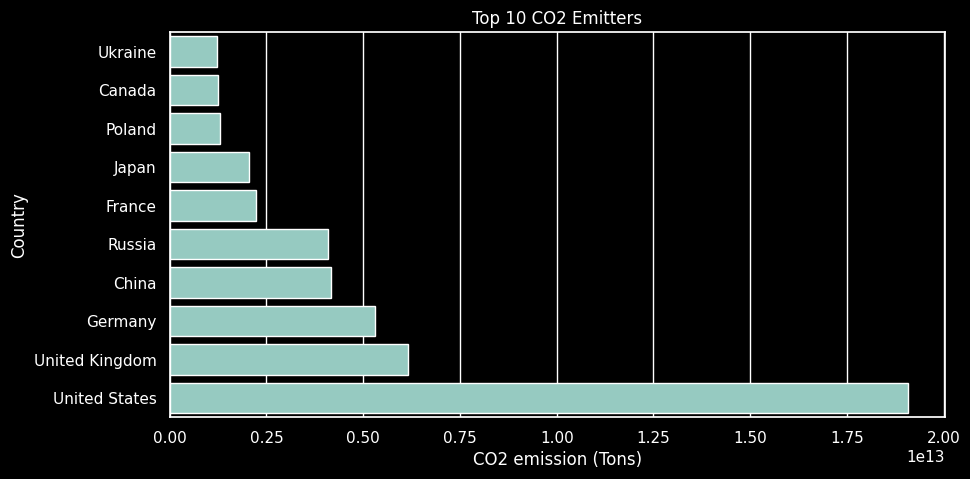

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="darkgrid")
plt.style.use("dark_background")

top_emitters = (
    cleanedco2.groupby("Country")["CO2 emission (Tons)"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10,5))
sns.barplot(
    data=top_emitters,
    x="CO2 emission (Tons)",
    y="Country",
    order=top_emitters.sort_values("CO2 emission (Tons)")["Country"]
)

plt.title("Top 10 CO2 Emitters")
plt.show()

Yearly trend

In [83]:
cleanedco2.groupby("Year")["CO2 emission (Tons)"] \
          .sum()

,CO2 emission (Tons)
Year,
1750,9.350528e+06
1751,1.870106e+07
1752,2.805525e+07
1753,3.740944e+07
1754,4.676730e+07
...,...
2016,1.514282e+12
2017,1.548201e+12
2018,1.584224e+12


Line chart

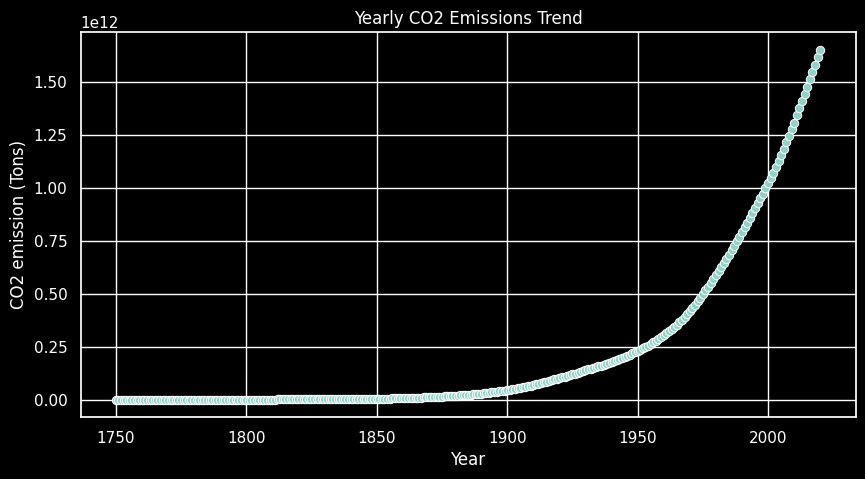

In [84]:
yearly = (
    cleanedco2.groupby("Year")["CO2 emission (Tons)"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10,5))
sns.lineplot(
    data=yearly,
    x="Year",
    y="CO2 emission (Tons)",
    marker="o"
)

plt.title("Yearly CO2 Emissions Trend")
plt.show()

United States CO2 Emissions Over Time

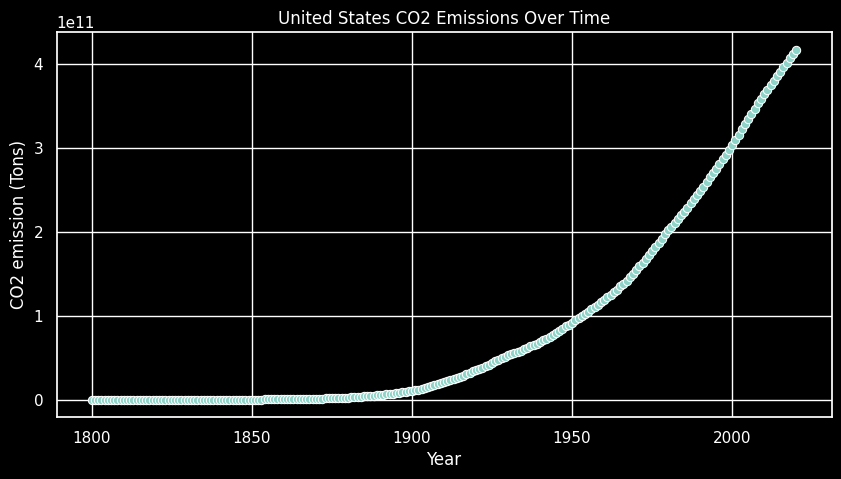

In [85]:
us = cleanedco2[cleanedco2["Country"] == "United States"]

us_yearly = (
    us.groupby("Year")["CO2 emission (Tons)"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10,5))
sns.lineplot(
    data=us_yearly,
    x="Year",
    y="CO2 emission (Tons)",
    marker="o"
)

plt.title("United States CO2 Emissions Over Time")
plt.show()

US Ranking each year

In [86]:
cleanedco2["rank"] = (
    cleanedco2.groupby("Year")["CO2 emission (Tons)"]
    .rank(ascending=False)
)

us_rank = cleanedco2[cleanedco2["Country"] == "United States"]

us_rank[["Year", "CO2 emission (Tons)", "rank"]]

,Year,CO2 emission (Tons),rank
56960,1800,2.528160e+05,4.0
56961,1801,5.202880e+05,4.0
56962,1802,8.097440e+05,6.0
56963,1803,1.106528e+06,6.0
56964,1804,1.439952e+06,6.0
...,...,...,...
57176,2016,3.960000e+11,1.0
57177,2017,4.010000e+11,1.0
57178,2018,4.070000e+11,1.0
57179,2019,4.120000e+11,1.0


Overall CO2 Emission Ranking

Outlier Detection

In [87]:
Q1 = cleanedco2["CO2 emission (Tons)"].quantile(0.25)
Q3 = cleanedco2["CO2 emission (Tons)"].quantile(0.75)

IQR = Q3 - Q1

outliers = cleanedco2[
    (cleanedco2["CO2 emission (Tons)"] < Q1 - 1.5*IQR) |
    (cleanedco2["CO2 emission (Tons)"] > Q3 + 1.5*IQR)
]

Detected Outliers

In [88]:
outliers

,Country,Year,CO2 emission (Tons),rank
785,Algeria,1993,1.467952e+09,46.0
786,Algeria,1994,1.554100e+09,45.0
787,Algeria,1995,1.649081e+09,45.0
788,Algeria,1996,1.745867e+09,44.0
789,Algeria,1997,1.832872e+09,45.0
...,...,...,...,...
58531,Vietnam,2016,3.043690e+09,50.0
58532,Vietnam,2017,3.238939e+09,49.0
58533,Vietnam,2018,3.462657e+09,49.0
58534,Vietnam,2019,3.722969e+09,49.0


The Outlier Shape

In [89]:
outliers.shape

(3617, 4)

Cheking which country dominates outliers

In [90]:
Dominating_outlier_countries = outliers["Country"].value_counts()

In [91]:
Dominating_outlier_countries.head()

,count
Country,
United Kingdom,201
United States,149
Germany,147
France,145
Belgium,122


Checking which year generates outliers

In [92]:
outliers["Year"].value_counts().sort_index()

,count
Year,
1820,1
1821,1
1822,1
1823,1
1824,1
...,...
2016,73
2017,73
2018,74


I want to confirm if this outliers are expected

In [93]:
cleanedco2.sort_values("CO2 emission (Tons)", ascending=False).head(20)

,Country,Year,CO2 emission (Tons),rank
57180,United States,2020,4.170000e+11,1.0
57179,United States,2019,4.120000e+11,1.0
57178,United States,2018,4.070000e+11,1.0
57177,United States,2017,4.010000e+11,1.0
57176,United States,2016,3.960000e+11,1.0
57175,United States,2015,3.910000e+11,1.0
57174,United States,2014,3.860000e+11,1.0
57173,United States,2013,3.800000e+11,1.0
57172,United States,2012,3.750000e+11,1.0
57171,United States,2011,3.690000e+11,1.0
